# NB4 — D'Arcy coverage finding: how much of the discordance case set do our resources label?

**Project:** pigmentation gene-network (genotype→phenotype discordance model)
**This notebook** is the single, runnable record of the D'Arcy-coverage finding. It recomputes the entire
chain from committed raw inputs and writes every derived table + the finding figure as its outputs. No loose
analyses: everything the finding cites is produced here.

---

## Direction labels (read this first)

The model's central claim is **bidirectional genotype→phenotype discordance**, measured in two directions.
These are abbreviated **D1** and **D2** throughout; both are always glossed:

- **D1 — "genotype-present, phenotype-absent."** The canonical *causal variant is present* but the expected
  pigmentation phenotype *does not appear* (reduced penetrance; downstream modifier nodes block the path).
- **D2 — "phenotype-present, genotype-absent."** The pigmentation phenotype *appears without* the canonical
  variant (an alternative gene/variant reaches the same endpoint).

At the **gene level**, two derived labels are used because a gene can appear in several papers:
- **`both`** — the gene has *both* D1-type (genotype-present/phenotype-absent) and D2-type
  (phenotype-present/genotype-absent) evidence across the case set.
- **`mixed`** — the direction *varies* across the papers/cases citing that gene.

`D2` never appears as a standalone gene-level value: every gene with D2 evidence is cited alongside D1
evidence somewhere, so it lands in `both` or `mixed`.

> **Naming note:** D1/D2 are placeholders. A clearer naming scheme is an open item; until it is chosen, every
> mention in prose and every figure legend spells out which direction is which.


## 0. Inputs and provenance

All inputs are committed to the repo:
- `data/raw/darcy2023/Table S1 …xlsx`, `Table S5 …xlsx` — D'Arcy & Kiel 2023, *Bioengineering* 10(1):13,
  DOI [10.3390/bioengineering10010013](https://doi.org/10.3390/bioengineering10010013), PMC9854651, CC BY 4.0.
- `data/processed/gene_network_nodes.csv` — the NB2 168-gene mechanistic network (built in NB2).
- `data/case_records/EXTRACT_*.csv` (13 files) + `data/processed/discordance_case_classification.csv` — the
  694-record case set (built in NB3).
- `data/processed/case_gene_id_resolution.csv` — canonical ID resolution of the 31 case-gene symbols via
  MyGene.info/HGNC (network step, run once and committed; see the `notes` column for alias corrections).

**Scope rule (locked decision 5):** D'Arcy is used here *only* as a disease-direction **annotation layer**
(Table S1, the OMIM-backed disease-gene table). Its STRING-derived interaction edges (Tables S4/S5) are
**excluded** from the mechanistic network — they are computationally predicted, not literature-curated. This
notebook adds annotation columns to gene lists; it never creates or imports a network edge.


In [1]:
import pandas as pd, numpy as np, os
from pathlib import Path

# repo-root-relative paths so the notebook runs from anywhere in the repo
ROOT = Path.cwd()
while not (ROOT / "data" / "raw" / "darcy2023").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw" / "darcy2023"
PROC = ROOT / "data" / "processed"
CASES = ROOT / "data" / "case_records"
FIGS = ROOT / "figures"; FIGS.mkdir(exist_ok=True)
print("repo root:", ROOT.name)

repo root: pigmentation-gene-network


## 1. Parse D'Arcy Table S1 (disease-direction annotation) and Table S5 (expanded PPI node list)

In [2]:
def load_darcy(fn, header=2):
    d = pd.read_excel(RAW / fn, header=header)
    d.columns = [str(c).strip() for c in d.columns]
    d = d.rename(columns={d.columns[0]: "gene"})
    return d

s1 = load_darcy("Table S1 Bioengineering FINAL.xlsx")
s1.columns = ["gene","disease_name","inheritance","phenotype_mim",
              "phenotype_class","pigmentation_phenotype","source"][:len(s1.columns)]
s5 = load_darcy("Table S5 Bioengineering FINAL.xlsx")

s1_genes = set(s1["gene"].dropna().astype(str).str.strip()) - {"nan",""}
s5_genes = set(s5["gene"].dropna().astype(str).str.strip()) - {"nan",""}
darcy_union = s1_genes | s5_genes
print(f"D'Arcy S1 genes = {len(s1_genes)}  |  S5 genes = {len(s5_genes)}  |  union = {len(darcy_union)}")
assert len(s1_genes) == 243 and len(s5_genes) == 451 and len(darcy_union) == 508

print("\nS1 phenotype-class distribution (the disease-direction axis):")
print(s1["phenotype_class"].value_counts().to_string())

D'Arcy S1 genes = 243  |  S5 genes = 451  |  union = 508

S1 phenotype-class distribution (the disease-direction axis):
phenotype_class
Hypopigmentation disorder                   144
Hyperpigmentation disorder                   81
Mixed hypo- & hyperpigmentation disorder     47
Pigmentation phenotype                        6


## 2. Load the NB2 mechanistic network and reproduce the D'Arcy × backbone cross-check

In [3]:
nodes = pd.read_csv(PROC / "gene_network_nodes.csv")
net_genes = set(nodes["gene"].dropna().astype(str).str.strip())
print(f"NB2 network genes = {len(net_genes)}")

absent      = darcy_union - net_genes                 # D'Arcy genes NOT in the mechanistic backbone
s1_hypo     = set(s1.loc[s1["phenotype_class"].astype(str).str.contains("Hypopig", na=False), "gene"])
absent_dis  = absent & s1_genes                        # of those, disease-flagged (have an S1 row)
absent_hypo = absent & s1_hypo                          # of those, hypopigmentation-class

crosscheck = pd.DataFrame([
    {"metric":"darcy_S1_genes","value":len(s1_genes)},
    {"metric":"darcy_S5_genes","value":len(s5_genes)},
    {"metric":"darcy_union_genes","value":len(darcy_union)},
    {"metric":"nb2_network_genes","value":len(net_genes)},
    {"metric":"union_absent_from_backbone","value":len(absent)},
    {"metric":"disease_flagged_among_absent","value":len(absent_dis)},
    {"metric":"hypopigmentation_class_among_absent","value":len(absent_hypo)},
    {"metric":"darcy_union_overlap_backbone","value":len(darcy_union & net_genes)},
])
crosscheck.to_csv(PROC / "darcy_backbone_crosscheck.csv", index=False)
print(crosscheck.to_string(index=False))
# Reproduces the reported figures (dashboard's earlier 230 was a synonym-resolution artifact; 227 is correct)
assert len(absent) == 465 and len(absent_dis) == 227 and len(absent_hypo) == 118
print("\nCross-check reproduces: 465 absent / 227 disease-flagged / 118 hypopigmentation-class.")

NB2 network genes = 168
                             metric  value
                     darcy_S1_genes    243
                     darcy_S5_genes    451
                  darcy_union_genes    508
                  nb2_network_genes    168
         union_absent_from_backbone    465
       disease_flagged_among_absent    227
hypopigmentation_class_among_absent    118
       darcy_union_overlap_backbone     43

Cross-check reproduces: 465 absent / 227 disease-flagged / 118 hypopigmentation-class.


## 3. Attach S1 disease-direction to the backbone-overlapping genes (annotation layer only)

The 43 genes present in **both** D'Arcy union and the mechanistic network get an S1 disease-direction
annotation column. This adds a column to a gene list — it does **not** touch network topology or import any
edge.

In [4]:
overlap = sorted(darcy_union & net_genes)
# Per-gene disease-direction normalization (a gene may have several S1 disease rows).
# Rule (reproduces the verified coverage artifact exactly, 0 mismatches):
#   Mixed if the gene has a "Mixed ..." row, a "Pigmentation phenotype" row, OR both hypo- and hyper- rows;
#   else Hypopigmentation / Hyperpigmentation as applicable.
g2classes = {}
for _, r in s1.iterrows():
    g = str(r["gene"]).strip(); cl = str(r["phenotype_class"]).strip()
    if g and g != "nan" and cl and cl != "nan":
        g2classes.setdefault(g, set()).add(cl)

def darcy_direction(gene):
    classes = g2classes.get(gene)
    if not classes:
        return np.nan
    has_hypo  = any("Hypopig"  in c for c in classes)
    has_hyper = any("Hyperpig" in c for c in classes)
    has_mixed = any(c.startswith("Mixed") or c == "Pigmentation phenotype" for c in classes)
    if has_mixed or (has_hypo and has_hyper): return "Mixed"
    if has_hypo:  return "Hypopigmentation"
    if has_hyper: return "Hyperpigmentation"
    return "Mixed"

s1_dir = {g: darcy_direction(g) for g in g2classes}
ann = pd.DataFrame({"gene": overlap})
ann["in_backbone_168"] = True
ann["in_darcy_S1"] = ann["gene"].isin(s1_genes)
ann["in_darcy_S5"] = ann["gene"].isin(s5_genes)
ann["s1_phenotype_class"] = ann["gene"].map(s1_dir)   # blank if S5-only (annotation only; not imputed)
ann.to_csv(PROC / "darcy_S1_direction_on_backbone.csv", index=False)
assert len(ann) == 43
print(f"{len(ann)} backbone∩D'Arcy genes annotated with disease direction (no edges created).")
print(ann.head(10).to_string(index=False))

43 backbone∩D'Arcy genes annotated with disease direction (no edges created).
  gene  in_backbone_168  in_darcy_S1  in_darcy_S5 s1_phenotype_class
BCL2L1             True        False         True                NaN
 CASP8             True        False         True                NaN
  CDK2             True        False         True                NaN
  CDK4             True        False         True                NaN
  CHUK             True        False         True                NaN
CTNNB1             True        False         True                NaN
  EDN1             True        False         True                NaN
 EDNRB             True         True         True   Hypopigmentation
  EGFR             True        False         True                NaN
 EP300             True        False         True                NaN


## 4. Case genes: gather the 31 symbols, attach canonical IDs, assign coverage tiers

In [5]:
import re, glob
# Gather gene-like symbols across the 13 committed case-record extracts
extract_genes = set()
for f in glob.glob(str(CASES / "EXTRACT_*.csv")):
    d = pd.read_csv(f)
    for c in d.columns:
        if "gene" in c.lower():
            extract_genes |= set(d[c].dropna().astype(str).str.strip())
extract_genes = {g for g in extract_genes if re.fullmatch(r"[A-Z0-9]{2,10}", g)}

# Canonical IDs (committed MyGene/HGNC resolution; ORAOV1 -> LTO1 alias correction lives here)
res = pd.read_csv(PROC / "case_gene_id_resolution.csv")
sym_map = dict(zip(res["input_symbol"], res["resolved_official_symbol"]))
case_genes = sorted({sym_map.get(g, g) for g in extract_genes})
print(f"case-gene symbols found = {len(extract_genes)}  ->  canonical genes = {len(case_genes)}")
assert len(case_genes) == 31
print("alias/corrected during resolution:")
print(res.loc[res['match_type'].astype(str).str.contains('alias|synonym', case=False, na=False),
              ['input_symbol','resolved_official_symbol','notes']].to_string(index=False))

case-gene symbols found = 31  ->  canonical genes = 31
alias/corrected during resolution:
input_symbol resolved_official_symbol                                                                                                   notes
      ORAOV1                     LTO1 input 'ORAOV1' is a deprecated/alias symbol; resolved via alias scope to current official symbol 'LTO1'


In [6]:
# Coverage tier per case gene
def tier(g):
    if g in net_genes: return "in_network"
    if g in darcy_union: return "darcy_recoverable"
    return "dark_matter"

# discordance direction per gene, joined from the classification via the papers each gene appears in
cls = pd.read_csv(PROC / "discordance_case_classification.csv")
paper_dir = dict(zip(cls["paper"], cls["discordance_direction"]))
# map each canonical gene -> set of papers citing it
inv = {}
for f in glob.glob(str(CASES / "EXTRACT_*.csv")):
    paper = os.path.basename(f).replace("EXTRACT_","").replace("_records.csv","").replace(".csv","")
    d = pd.read_csv(f)
    syms = set()
    for c in d.columns:
        if "gene" in c.lower():
            syms |= set(d[c].dropna().astype(str).str.strip())
    for s in syms:
        g = sym_map.get(s, s)
        if re.fullmatch(r"[A-Z0-9]{2,10}", str(s)):
            inv.setdefault(g, set()).add(paper)

def case_direction(g):
    dirs = {paper_dir.get(p) for p in inv.get(g, set())} - {None}
    dirs = {str(x) for x in dirs}
    if not dirs: return "none"
    if dirs == {"D1"}: return "D1"
    if dirs == {"D2"}: return "D2"
    if dirs == {"both"}: return "both"
    return "mixed"   # more than one distinct direction across papers

id_map = res.drop_duplicates("resolved_official_symbol").set_index("resolved_official_symbol")
rows = []
for g in case_genes:
    rows.append({
        "gene": g,
        "entrez": id_map["entrez"].get(g, np.nan),
        "ensembl": id_map["ensembl"].get(g, ""),
        "in_nb2_network": g in net_genes,
        "in_darcy_union": g in darcy_union,
        "in_darcy_S1": g in s1_genes,
        "darcy_s1_phenotype_class": s1_dir.get(g, np.nan),
        "coverage_tier": tier(g),
        "case_papers": ";".join(sorted(inv.get(g, set()))),
        "case_discordance_direction": case_direction(g),
    })
cov = pd.DataFrame(rows).sort_values("gene").reset_index(drop=True)
cov.to_csv(PROC / "case_gene_coverage_master.csv", index=False)

counts = cov["coverage_tier"].value_counts()
print("coverage tiers:", counts.to_dict())
assert counts["in_network"]==9 and counts["darcy_recoverable"]==7 and counts["dark_matter"]==15
print(f"\nCoverage: {counts['in_network']}/31 in mechanistic network (29%); "
      f"+{counts['darcy_recoverable']} recovered by D'Arcy disease-direction -> 16/31 (52%); "
      f"{counts['dark_matter']}/31 dark matter.")

coverage tiers: {'dark_matter': 15, 'in_network': 9, 'darcy_recoverable': 7}

Coverage: 9/31 in mechanistic network (29%); +7 recovered by D'Arcy disease-direction -> 16/31 (52%); 15/31 dark matter.


## 5. Direction cross-tab: case discordance direction × D'Arcy disease direction

For the genes carrying **both** a case discordance direction and a D'Arcy disease class, tabulate the two
axes. These are co-occurrence counts across two differently-defined axes (population/case penetrance vs.
Mendelian disease direction) — **not** a concordance test, and no causal relationship is asserted.

In [7]:
dual = cov[(cov["case_discordance_direction"]!="none") & (cov["darcy_s1_phenotype_class"].notna())].copy()
only_case = cov[(cov["case_discordance_direction"]!="none") & (cov["darcy_s1_phenotype_class"].isna())]
neither  = cov[(cov["case_discordance_direction"]=="none") & (cov["darcy_s1_phenotype_class"].isna())]
print(f"genes with BOTH labels = {len(dual)}  |  only a case label = {len(only_case)}  |  neither = {len(neither)}")

xtab = pd.crosstab(dual["case_discordance_direction"], dual["darcy_s1_phenotype_class"])
print("\ncase direction (rows) x D'Arcy disease class (cols):")
print(xtab.to_string())
dual.to_csv(PROC / "direction_concordance.csv", index=False)
xtab.to_csv(PROC / "direction_concordance_matrix.csv")

genes with BOTH labels = 15  |  only a case label = 16  |  neither = 0

case direction (rows) x D'Arcy disease class (cols):
darcy_s1_phenotype_class    Hyperpigmentation  Hypopigmentation  Mixed
case_discordance_direction                                            
D1                                          0                 1      0
both                                        1                 5      1
mixed                                       0                 4      3


## 6. Finding figure — coverage-and-direction map

Each of the 31 case genes on one row, grouped by coverage tier. **Left marker colour = D'Arcy disease
direction** (blue Hypopigmentation / orange Hyperpigmentation / pink Mixed / open = absent from D'Arcy S1).
**Right marker shape = case discordance direction** — circle `both` (D1+D2), diamond `mixed`, triangle
**D1 (genotype-present, phenotype-absent)**. The two designated payoff loci (TYR, OCA2) and two further albinism genes (TYRP1, MC1R) are
highlighted in gold. Legends spell out D1/D2 in full.

saved: /Users/tlasisi/GitHub/pigmentation-gene-network/figures/case_coverage_direction_map.png


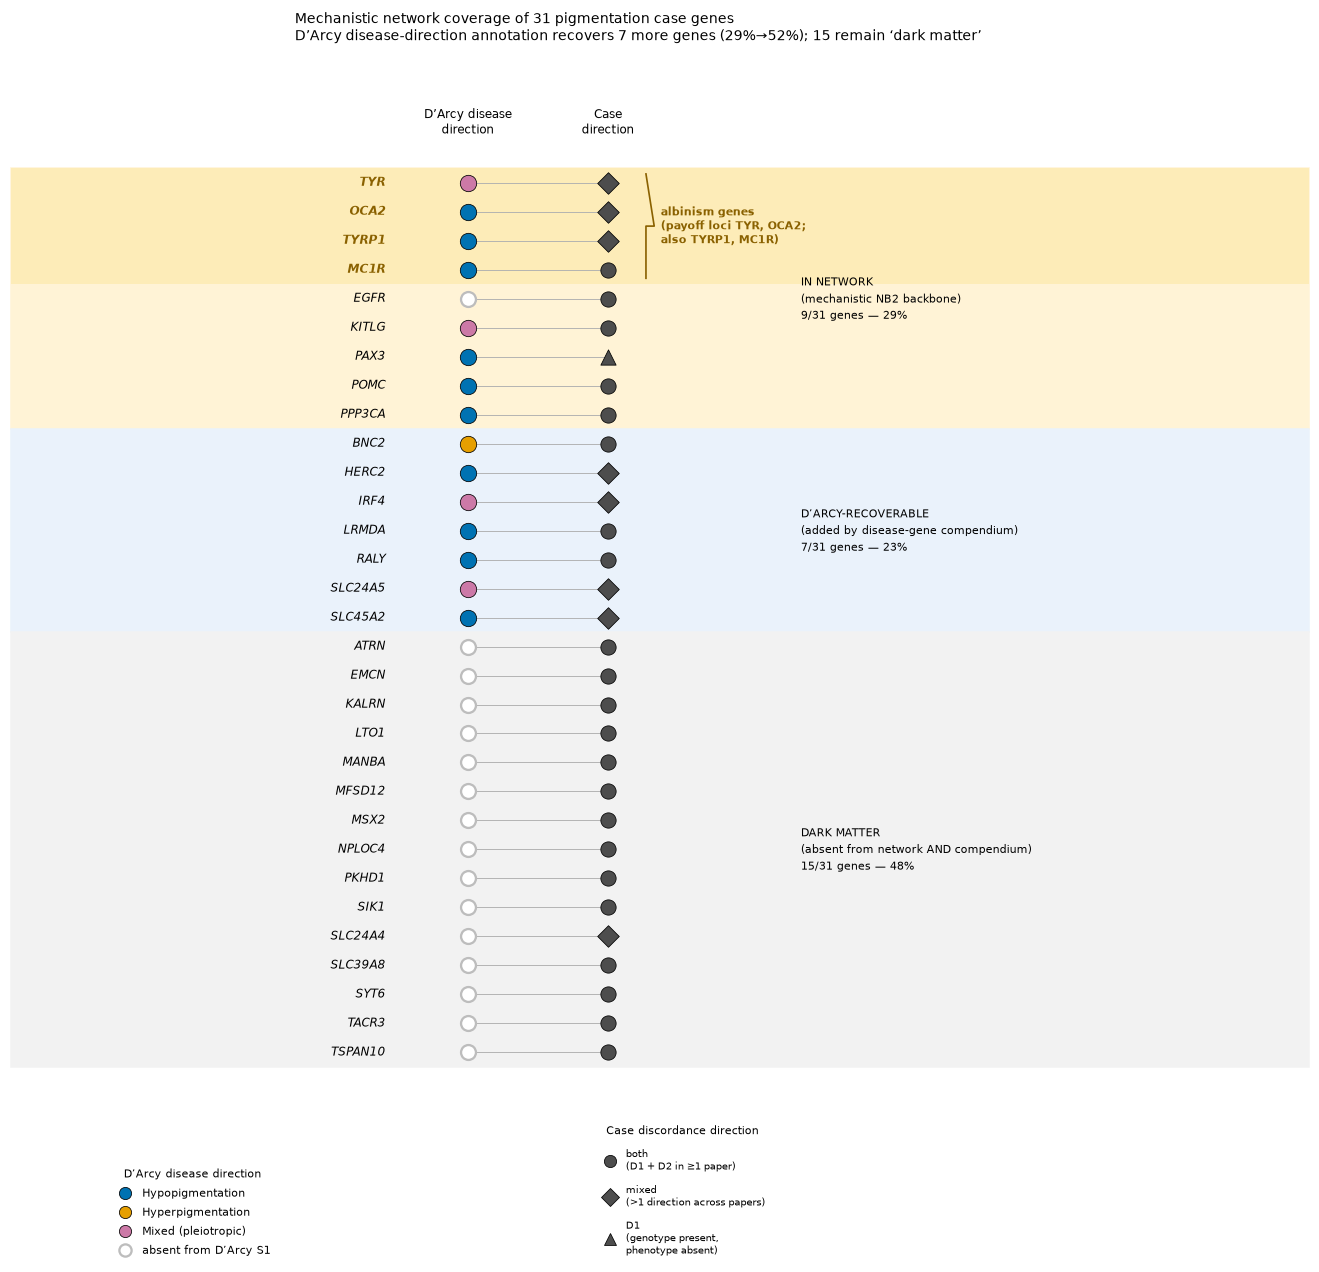

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# --- publication style (subset of figure-style skill) ---
mpl.rcParams.update({
    "font.family":"sans-serif","font.size":9,"axes.linewidth":0.6,
    "figure.dpi":150,"savefig.dpi":300,"savefig.bbox":"tight",
    "pdf.fonttype":42,"ps.fonttype":42,"legend.frameon":False,
})

df = cov[['gene','coverage_tier','in_nb2_network','in_darcy_S1','in_darcy_union',
          'darcy_s1_phenotype_class','case_discordance_direction']].copy()
df['disease_direction'] = df['darcy_s1_phenotype_class'].fillna('none')
df['case_direction'] = df['case_discordance_direction'].fillna('none')
albinism_loci = ['TYR','OCA2','TYRP1','MC1R']
df['is_albinism_payoff_locus'] = df['gene'].isin(albinism_loci)
tier_order = {'in_network':0,'darcy_recoverable':1,'dark_matter':2}
df['tier_rank'] = df['coverage_tier'].map(tier_order)
def sort_key(r):
    if r['is_albinism_payoff_locus']:
        return (r['tier_rank'],0,{'TYR':0,'OCA2':1,'TYRP1':2,'MC1R':3}[r['gene']],r['gene'])
    return (r['tier_rank'],1,0,r['gene'])
df['sort_tuple']=df.apply(sort_key,axis=1)
df=df.sort_values('sort_tuple').reset_index(drop=True)
n=len(df); df['y']=np.arange(n)[::-1]

COL_DISEASE={'Hypopigmentation':'#0072B2','Hyperpigmentation':'#E69F00','Mixed':'#CC79A7','none':'#BDBDBD'}
MARK_CASE={'both':'o','mixed':'D','D1':'^','D2':'v'}
CASE_LABELS={'both':'both\n(D1 + D2 in \u22651 paper)','mixed':'mixed\n(>1 direction across papers)',
             'D1':'D1\n(genotype present,\nphenotype absent)','D2':'D2\n(phenotype present,\ngenotype absent)'}
DISEASE_LABELS={'Hypopigmentation':'Hypopigmentation','Hyperpigmentation':'Hyperpigmentation',
                'Mixed':'Mixed (pleiotropic)','none':"absent from D\u2019Arcy S1"}
x_disease,x_case=0.0,0.85; row_h=1.0
tier_bands={t:(df.loc[df.coverage_tier==t,'y'].min(),df.loc[df.coverage_tier==t,'y'].max())
            for t in ['in_network','darcy_recoverable','dark_matter']}
band_colors={'in_network':'#FFF3D6','darcy_recoverable':'#EAF2FB','dark_matter':'#F2F2F2'}
tier_titles={'in_network':'IN NETWORK\n(mechanistic NB2 backbone)\n9/31 genes \u2014 29%',
             'darcy_recoverable':"D\u2019ARCY-RECOVERABLE\n(added by disease-gene compendium)\n7/31 genes \u2014 23%",
             'dark_matter':'DARK MATTER\n(absent from network AND compendium)\n15/31 genes \u2014 48%'}

fig,ax=plt.subplots(figsize=(9.6,11.8))
for tier,(ymin,ymax) in tier_bands.items():
    ax.axhspan(ymin-row_h/2,ymax+row_h/2,xmin=-0.42,xmax=1.5,color=band_colors[tier],zorder=0,clip_on=False)
alb=df[df.is_albinism_payoff_locus]; alb_ymin,alb_ymax=alb['y'].min(),alb['y'].max()
ax.axhspan(alb_ymin-row_h/2,alb_ymax+row_h/2,xmin=-0.42,xmax=1.5,facecolor='#FDE9A8',alpha=0.65,zorder=1,clip_on=False)
for _,r in df.iterrows(): ax.plot([x_disease,x_case],[r['y'],r['y']],color='#B0B0B0',lw=0.6,zorder=2)
for _,r in df.iterrows():
    col=COL_DISEASE[r['disease_direction']]
    if r['disease_direction']=='none':
        ax.scatter(x_disease,r['y'],s=95,facecolors='white',edgecolors=col,linewidths=1.5,marker='o',zorder=3)
    else:
        ax.scatter(x_disease,r['y'],s=115,facecolors=col,edgecolors='black',linewidths=0.5,marker='o',zorder=3)
for _,r in df.iterrows():
    ax.scatter(x_case,r['y'],s=100,facecolors='#4D4D4D',edgecolors='black',linewidths=0.5,
               marker=MARK_CASE[r['case_direction']],zorder=3)
for _,r in df.iterrows():
    w='bold' if r['is_albinism_payoff_locus'] else 'normal'; c='#8A6100' if r['is_albinism_payoff_locus'] else 'black'
    ax.text(-0.5,r['y'],r['gene'],ha='right',va='center',fontweight=w,fontstyle='italic',fontsize=8,zorder=4,color=c)
bx=1.08
ax.plot([bx,bx,bx+0.05,bx],[alb_ymin-0.3,(alb_ymin+alb_ymax)/2,(alb_ymin+alb_ymax)/2,alb_ymax+0.3],color='#8A6100',lw=1.1,zorder=4,clip_on=False)
ax.text(bx+0.09,(alb_ymin+alb_ymax)/2,"albinism genes\n(payoff loci TYR, OCA2;\nalso TYRP1, MC1R)",ha='left',va='center',fontsize=7.3,fontweight='bold',color='#8A6100',zorder=4)
ax.text(x_disease,n+0.55,"D\u2019Arcy disease\ndirection",ha='center',va='bottom',fontsize=8)
ax.text(x_case,n+0.55,"Case\ndirection",ha='center',va='bottom',fontsize=8)
for tier,(ymin,ymax) in tier_bands.items():
    ax.text(2.02,(ymin+ymax)/2,tier_titles[tier],ha='left',va='center',fontsize=7.5,linespacing=1.5)
ax.set_xlim(-1.05,3.05); ax.set_ylim(-1.1,n+1.7); ax.set_yticks([]); ax.set_xticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.set_title("Mechanistic network coverage of 31 pigmentation case genes\n"
             "D\u2019Arcy disease-direction annotation recovers 7 more genes (29%\u219252%); 15 remain \u2018dark matter\u2019",
             fontsize=9,loc='left',pad=42)
disease_handles=[Line2D([0],[0],marker='o',color='none',markerfacecolor=COL_DISEASE[k],markeredgecolor='black',
                        markeredgewidth=0.5,markersize=8,label=DISEASE_LABELS[k]) for k in ['Hypopigmentation','Hyperpigmentation','Mixed']]
disease_handles.append(Line2D([0],[0],marker='o',color='none',markerfacecolor='white',markeredgecolor=COL_DISEASE['none'],markeredgewidth=1.5,markersize=8,label=DISEASE_LABELS['none']))
case_present=[k for k in ['both','mixed','D1','D2'] if k in df['case_direction'].unique()]
case_handles=[Line2D([0],[0],marker=MARK_CASE[k],color='none',markerfacecolor='#4D4D4D',markeredgecolor='black',markeredgewidth=0.5,markersize=8,label=CASE_LABELS[k]) for k in case_present]
fig.legend(handles=disease_handles,title="D\u2019Arcy disease direction",loc='lower left',bbox_to_anchor=(0.06,0.005),fontsize=7,title_fontsize=7.5,labelspacing=0.7,handletextpad=0.6)
fig.legend(handles=case_handles,title="Case discordance direction",loc='lower left',bbox_to_anchor=(0.52,0.005),fontsize=6.6,title_fontsize=7.5,labelspacing=1.1,handletextpad=0.6)
fig.subplots_adjust(left=0.24,right=0.88,top=0.90,bottom=0.145)
alt_text=("Coverage map of 31 pigmentation case genes across three tiers: in_network (9, 29%), "
          "darcy_recoverable (7, cumulative 52%), dark_matter (15, 48%). Left marker colour = D'Arcy disease "
          "direction; right marker shape = case discordance direction (circle both, diamond mixed, triangle "
          "D1=genotype-present/phenotype-absent). Albinism loci TYR/OCA2/TYRP1/MC1R highlighted.")
fig.savefig(FIGS / "case_coverage_direction_map.png", dpi=300, metadata={'Description':alt_text})
plt.show()
print("saved:", FIGS / "case_coverage_direction_map.png")

## 7. Finding, in one paragraph

The mechanistic NB2 network covers **9/31 (29%)** of the discordance case genes. Adding D'Arcy & Kiel (2023)
Table S1 disease-direction labels as an **annotation layer** (STRING edge tables S4/S5 stay excluded) recovers
a direction label for **7 more genes → 16/31 (52%)**. **15 genes are "dark matter"** — absent from *both* the
mechanistic network and the OMIM-backed disease-gene compendium — yet every one carries a discordance
direction in the case literature. That gap is the concrete target for the next stage: the genes that carry the
discordance signal are disproportionately the ones our current resources do not contain. This is a
coverage/annotation observation, not a causal or predictive claim.

Full narrative writeup: `internal/FINDINGS_darcy_coverage.md`.


## 8. Where each paper fits

The coverage finding above draws on the full 13-paper, 694-record validation-case set. The worked examples
lean on Ang 2023 (7 of the 15 dark-matter genes: ATRN, EMCN, KALRN, MANBA, SLC39A8, SYT6, TACR3) because
that is where the dark matter physically concentrates, not because the corpus is Ang-centric — Ang 2023
(53 records) is only the fourth-largest paper; Meyer 2020 (211 records), Kastelic 2013 (105 records), and
Morgan 2018 (63 records) are all larger. The 13 papers cluster by phenotype system:

| cluster | papers | role in the finding |
|---|---|---|
| Eye-colour / forensic panel | Abbatangelo 2026, Meyer 2020, Pospiech 2016, Kastelic 2013, Salvo 2023 | Nearest-gene≠causal story (HERC2→OCA2); IRF4/SLC24A4/TSPAN10 dark matter |
| Skin pigmentation (population) | Crawford 2017, Yang 2016 | Genuinely-novel dark matter: MFSD12, SLC24A5/SLC45A2 |
| Albinism / hypopigmentation | Ang 2023 | LD-passenger/no-signal dark matter + the OCA2 D1/D2 anchor |
| Blond hair (TYRP1) | Kenny 2012, Norton 2014, Norton 2016 | D2 depth on one in-network gene (TYRP1) — not dark matter |
| Red hair (MC1R) | Morgan 2018 | D1 depth on MC1R + a second dark-matter engine (LTO1/MSX2/PKHD1/SIK1/TSPAN10 — TSPAN10 also contributed by Abbatangelo 2026, so paper-level counts overlap) |
| Syndromic | Morell 1997 (Waardenburg, PAX3) | Clean D1 anchor on an in-network gene |

Two caveats: Kastelic 2013 extracted **0 gene symbols** (model/marker paper, no gene column) and must not
be read as an independent gene contribution; the three TYRP1 papers collapse to one in-network gene
(D2 depth, not breadth). Full evaluation: `internal/FRAMING_EVALUATION_dark_matter.md`.
